In [ ]:
# Setup
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import os
import matplotlib.pyplot as plt
import re
import seaborn as sns
import pylab
from cycler import cycler
from matplotlib.ticker import ScalarFormatter, LogLocator, FuncFormatter
import matplotlib as mpl

mpl.rcParams['font.family'] = 'Arial'
# === Plot Styling ===
params = {
    'legend.fontsize': 8,       # Small legend text for compactness
    'figure.figsize': (6.5, 3),  # Figure size (in inches)
    'axes.labelsize': 8,       # Axis labels (X/Y)
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    # 'xtick.major.size': 8,
    # 'ytick.major.size': 8,    
    'axes.titlesize': 8,       # Title size
    'xtick.labelsize': 8,      # X-axis tick labels
    'ytick.labelsize': 8,      # Y-axis tick labels
    'lines.markersize': 5,     # Marker size
    'lines.linewidth': 1        # Line width
}
pylab.rcParams.update(params)

# === Set Random Seed ===
np.random.seed(42)

# === Custom Color Palette ===
custom_palette = [
    "#E69F00",  # orange
    "#009E73",  # bluish green
    "#CC79A7",  # pink
    "#0072B2",  # blue
    "#D55E00",  # vermillion
    "#56B4E9",  # sky blue
    "#7A1F63"  # reddish purple
]

def rotate_points(x, y, theta_deg):
    theta = np.deg2rad(theta_deg)
    x_rot = x * np.cos(theta) + y * np.sin(theta)
    y_rot = -x * np.sin(theta) + y * np.cos(theta)
    return x_rot, y_rot


sns.set_palette(custom_palette)
# Line styles to cycle through
linestyles = ['-', '-','-', '--', '-.', ':', '-']
sealines = ['', '', (6, 4), (6, 4), (3, 5, 1, 5), (1, 3), '']
# Combine colors and linestyles using cycler
plt.rcParams['axes.prop_cycle'] = cycler(color=custom_palette) + cycler(linestyle=linestyles)


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

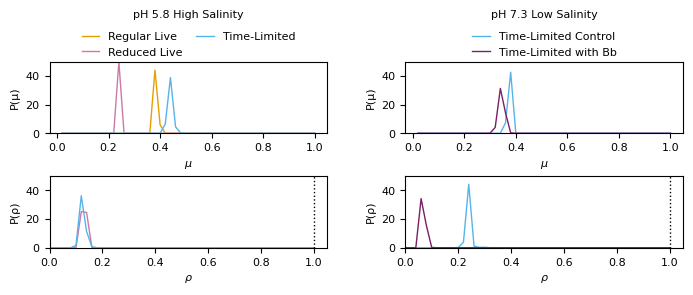

In [38]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import logsumexp

base_dir = "grid_likelihood_outputs"

title_map = {
    "Exp_1_live_lowpH": "Regular Live",
    "Exp_2_reduced_live_lowpH": "Reduced Live",
    "Exp_3_time-limited_lowpH": "Time-Limited",
    "Exp_4_live_highpH": "Regular Live (high pH)",
    "Exp_7_low-salinity_time-limited": "Time-Limited Control",
    "Exp_8_BB_low-salinity_time-limited": "Time-Limited with Bb",
}

color_map = {
    "Exp_1_live_lowpH": "#E69F00",
    "Exp_2_reduced_live_lowpH": "#CC79A7",
    #"Exp_3_time-limited_lowpH": "#0072B2",
    "Exp_3_time-limited_lowpH": "#56B4E9",
    "Exp_4_live_highpH":"#E69F00",# "#D55E00",
    "Exp_7_low-salinity_time-limited": "#56B4E9",
    "Exp_8_BB_low-salinity_time-limited": "#7A1F63",
}

mu_group_1 = [
    "Exp_1_live_lowpH",
    "Exp_2_reduced_live_lowpH",
    "Exp_3_time-limited_lowpH",
]

mu_group_2 = [
    "Exp_7_low-salinity_time-limited",
    "Exp_8_BB_low-salinity_time-limited",
]

rho_group_1 = [
    "Exp_2_reduced_live_lowpH",
    "Exp_3_time-limited_lowpH",
]

rho_group_2 = [
    "Exp_7_low-salinity_time-limited",
    "Exp_8_BB_low-salinity_time-limited",
]


def load_1d_mu(dataset_name):
    path = os.path.join(base_dir, dataset_name, "grid_zomega.csv")
    df = pd.read_csv(path).copy().sort_values("mu")

    mu = df["mu"].to_numpy()
    loglike = np.nan_to_num(df["loglike"].to_numpy(), neginf=-1e6)

    dmu = mu[1] - mu[0]
    Pmu = np.exp(loglike - logsumexp(loglike) - np.log(dmu))
    return mu, Pmu


def load_2d_marginals(dataset_name):
    path = os.path.join(base_dir, dataset_name, "grid_zomega.csv")
    df = pd.read_csv(path).copy()

    pivot = df.pivot(index="mu", columns="rho", values="loglike")
    pivot = pivot.sort_index().sort_index(axis=1)

    mus = pivot.index.to_numpy()
    rhos = pivot.columns.to_numpy()
    Z = np.nan_to_num(pivot.to_numpy(), neginf=-1e6)

    dmu = mus[1] - mus[0]
    drho = rhos[1] - rhos[0]

    logZtot = logsumexp(Z)
    logP_mu = logsumexp(Z, axis=1) - logZtot - np.log(dmu)
    logP_rho = logsumexp(Z, axis=0) - logZtot - np.log(drho)

    return mus, rhos, np.exp(logP_mu), np.exp(logP_rho)


# -----------------------------
# Load curves
# -----------------------------
mu_curves = {}
rho_curves = {}

for ds in ["Exp_1_live_lowpH", "Exp_4_live_highpH"]:
    mu_curves[ds] = load_1d_mu(ds)

for ds in [
    "Exp_2_reduced_live_lowpH",
    "Exp_3_time-limited_lowpH",
    "Exp_7_low-salinity_time-limited",
    "Exp_8_BB_low-salinity_time-limited",
]:
    mus, rhos, Pmu, Prho = load_2d_marginals(ds)
    mu_curves[ds] = (mus, Pmu)
    rho_curves[ds] = (rhos, Prho)

# -----------------------------
# Plot
# -----------------------------
fig, axes = plt.subplots(2, 2, figsize=(7.2, 3.0))
ax_mu1, ax_mu2, ax_rho1, ax_rho2 = axes.ravel()

# Spacing
plt.subplots_adjust(left=0.10, right=0.98, bottom=0.16, top=0.78, wspace=0.28, hspace=0.60)

for ax in axes.ravel():
    ax.set_ylim(0, 50)
    ax.tick_params(direction="out")

# ---- P(mu): Exp 1,2,3 ----
for ds in mu_group_1:
    x, y = mu_curves[ds]
    ax_mu1.plot(x, y, color=color_map[ds], label=title_map[ds])

ax_mu1.set_xlabel(r"$\mu$")
ax_mu1.set_ylabel("P(μ)")

# ---- P(mu): Exp 7,8 ----
for ds in mu_group_2:
    x, y = mu_curves[ds]
    ax_mu2.plot(x, y, color=color_map[ds], label=title_map[ds])

ax_mu2.set_xlabel(r"$\mu$")
ax_mu2.set_ylabel("P(μ)")

# ---- P(rho): Exp 2 vs 3 ----
for ds in rho_group_1:
    x, y = rho_curves[ds]
    ax_rho1.plot(x, y, color=color_map[ds], label=title_map[ds])

ax_rho1.axvline(1.0, color="black", linestyle=":", linewidth=1)
ax_rho1.set_xlabel(r"$\rho$")
ax_rho1.set_ylabel("P(ρ)")

# ---- P(rho): Exp 7 vs 8 ----
for ds in rho_group_2:
    x, y = rho_curves[ds]
    ax_rho2.plot(x, y, color=color_map[ds], label=title_map[ds])

ax_rho2.axvline(1.0, color="black", linestyle=":", linewidth=1)
ax_rho2.set_xlabel(r"$\rho$")
ax_rho2.set_ylabel("P(ρ)")

# Make sure rho=1 line is visible
ax_rho1.set_xlim(0, max(1.05, ax_rho1.get_xlim()[1]))
ax_rho2.set_xlim(0, max(1.05, ax_rho2.get_xlim()[1]))

# optional: cleaner right column by removing repeated y tick labels
# ax_mu2.set_ylabel("")
# ax_rho2.set_ylabel("")

# -----------------------------
# Legends attached to top axes
# -----------------------------
leg1 = ax_mu1.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, 1),
    ncol=2,
    frameon=False,
    handlelength=1.6,
    columnspacing=1.2,
    borderaxespad=0.0
)

leg2 = ax_mu2.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, 1),
    ncol=1,
    frameon=False,
    handlelength=1.6,
    columnspacing=1.2,
    borderaxespad=0.0
)

# -----------------------------
# Column titles above legends
# -----------------------------
fig.canvas.draw()

bbox1 = ax_mu1.get_position()
bbox2 = ax_mu2.get_position()

fig.text(
    bbox1.x0 + bbox1.width / 2,
    bbox1.y1 + 0.14,
    "pH 5.8 High Salinity",
    ha="center",
    va="bottom"
)

fig.text(
    bbox2.x0 + bbox2.width / 2,
    bbox2.y1 + 0.14,
    "pH 7.3 Low Salinity",
    ha="center",
    va="bottom"
)

plt.savefig(
    os.path.join(base_dir, "mu_rho_grouped_comparisons.png"),
    dpi=500,
    bbox_inches="tight"
)
plt.show()

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

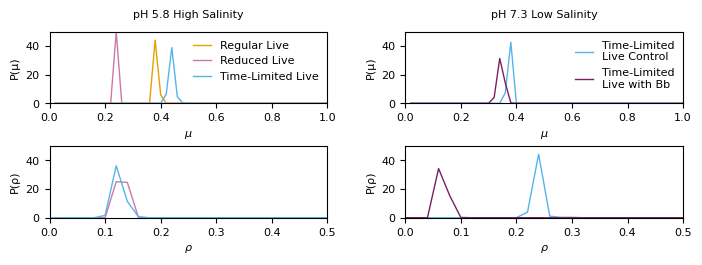

In [ ]:
# Alternative plot
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import logsumexp

base_dir = "grid_likelihood_outputs"

title_map = {
    "Exp_1_live_lowpH": "Regular Live",
    "Exp_2_reduced_live_lowpH": "Reduced Live",
    "Exp_3_time-limited_lowpH": "Time-Limited Live",
    "Exp_4_live_highpH": "Regular Live (high pH)",
    "Exp_7_low-salinity_time-limited": "Time-Limited\nLive",
    "Exp_8_BB_low-salinity_time-limited": "Time-Limited\nLive with Bb",
}

color_map = {
    "Exp_1_live_lowpH": "#E69F00",
    "Exp_2_reduced_live_lowpH": "#CC79A7",
    #"Exp_3_time-limited_lowpH": "#0072B2",
    "Exp_3_time-limited_lowpH": "#56B4E9",
    "Exp_4_live_highpH":"#E69F00",# "#D55E00",
    "Exp_7_low-salinity_time-limited": "#56B4E9",
    "Exp_8_BB_low-salinity_time-limited": "#7A1F63",
}

mu_group_1 = [
    "Exp_1_live_lowpH",
    "Exp_2_reduced_live_lowpH",
    "Exp_3_time-limited_lowpH",
]

mu_group_2 = [
    "Exp_7_low-salinity_time-limited",
    "Exp_8_BB_low-salinity_time-limited",
]

rho_group_1 = [
    "Exp_2_reduced_live_lowpH",
    "Exp_3_time-limited_lowpH",
]

rho_group_2 = [
    "Exp_7_low-salinity_time-limited",
    "Exp_8_BB_low-salinity_time-limited",
]


def load_1d_mu(dataset_name):
    path = os.path.join(base_dir, dataset_name, "grid_zomega.csv")
    df = pd.read_csv(path).copy().sort_values("mu")

    mu = df["mu"].to_numpy()
    loglike = np.nan_to_num(df["loglike"].to_numpy(), neginf=-1e6)

    dmu = mu[1] - mu[0]
    Pmu = np.exp(loglike - logsumexp(loglike) - np.log(dmu))
    return mu, Pmu


def load_2d_marginals(dataset_name):
    path = os.path.join(base_dir, dataset_name, "grid_zomega.csv")
    df = pd.read_csv(path).copy()

    pivot = df.pivot(index="mu", columns="rho", values="loglike")
    pivot = pivot.sort_index().sort_index(axis=1)

    mus = pivot.index.to_numpy()
    rhos = pivot.columns.to_numpy()
    Z = np.nan_to_num(pivot.to_numpy(), neginf=-1e6)

    dmu = mus[1] - mus[0]
    drho = rhos[1] - rhos[0]

    logZtot = logsumexp(Z)
    logP_mu = logsumexp(Z, axis=1) - logZtot - np.log(dmu)
    logP_rho = logsumexp(Z, axis=0) - logZtot - np.log(drho)

    return mus, rhos, np.exp(logP_mu), np.exp(logP_rho)


# -----------------------------
# Load curves
# -----------------------------
mu_curves = {}
rho_curves = {}

for ds in ["Exp_1_live_lowpH", "Exp_4_live_highpH"]:
    mu_curves[ds] = load_1d_mu(ds)

for ds in [
    "Exp_2_reduced_live_lowpH",
    "Exp_3_time-limited_lowpH",
    "Exp_7_low-salinity_time-limited",
    "Exp_8_BB_low-salinity_time-limited",
]:
    mus, rhos, Pmu, Prho = load_2d_marginals(ds)
    mu_curves[ds] = (mus, Pmu)
    rho_curves[ds] = (rhos, Prho)

# -----------------------------
# Plot
# -----------------------------
fig, axes = plt.subplots(2, 2, figsize=(7.2, 3.0))
ax_mu1, ax_mu2, ax_rho1, ax_rho2 = axes.ravel()

plt.subplots_adjust(left=0.10, right=0.98, bottom=0.16, top=0.78, wspace=0.28, hspace=0.60)

for ax in axes.ravel():
    ax.set_ylim(0, 50)
    ax.tick_params(direction="out")

# ---- P(mu): Exp 1,2,3 ----
for ds in mu_group_1:
    x, y = mu_curves[ds]
    ax_mu1.plot(x, y, color=color_map[ds], label=title_map[ds])

ax_mu1.set_xlabel(r"$\mu$")
ax_mu1.set_ylabel("P(μ)")
ax_mu1.set_xlim(0, 1.0)

# ---- P(mu): Exp 7,8 ----
for ds in mu_group_2:
    x, y = mu_curves[ds]
    ax_mu2.plot(x, y, color=color_map[ds], label=title_map[ds])

ax_mu2.set_xlabel(r"$\mu$")
ax_mu2.set_ylabel("P(μ)")
ax_mu2.set_xlim(0, 1.0)

# ---- P(rho): Exp 2 vs 3 ----
for ds in rho_group_1:
    x, y = rho_curves[ds]
    ax_rho1.plot(x, y, color=color_map[ds], label=title_map[ds])

ax_rho1.set_xlabel(r"$\rho$")
ax_rho1.set_ylabel("P(ρ)")
ax_rho1.set_xlim(0, 0.5)

# ---- P(rho): Exp 7 vs 8 ----
for ds in rho_group_2:
    x, y = rho_curves[ds]
    ax_rho2.plot(x, y, color=color_map[ds], label=title_map[ds])

ax_rho2.set_xlabel(r"$\rho$")
ax_rho2.set_ylabel("P(ρ)")
ax_rho2.set_xlim(0, 0.5)

# optional: cleaner right column by removing repeated y tick labels
# ax_mu2.set_ylabel("")
# ax_rho2.set_ylabel("")

# -----------------------------
# Legends inside top plots
# -----------------------------
ax_mu1.legend(
    loc="upper right",
    frameon=False,
    handlelength=1.6,
    borderaxespad=0.4
)

ax_mu2.legend(
    loc="upper right",
    frameon=False,
    handlelength=1.6,
    borderaxespad=0.4
)

# -----------------------------
# Column titles
# -----------------------------
fig.canvas.draw()
bbox1 = ax_mu1.get_position()
bbox2 = ax_mu2.get_position()

fig.text(
    bbox1.x0 + bbox1.width / 2,
    bbox1.y1 + 0.04,
    "pH 5.8 High Salinity",
    ha="center",
    va="bottom"
)

fig.text(
    bbox2.x0 + bbox2.width / 2,
    bbox2.y1 + 0.04,
    "pH 7.3 Low Salinity",
    ha="center",
    va="bottom"
)

plt.savefig(
    os.path.join(base_dir, "mu_rho_grouped_comparisons.png"),
    dpi=500,
    bbox_inches="tight"
)
plt.show()